# Manufacturing Stress: Adaptive Model Comparison

Controlled lite-versus-advanced adaptive comparison. Mutation is disabled; both predictors use the same frozen strategy and historical origins. In the setup cell, set `BACKTEST_STRIDE_MONTHS` to `3` for the faster default (28 origins) or `1` for monthly origins (84 origins). The three-month forecast horizon is unchanged, so monthly targets overlap.

The final paired table compares each model's predicted probability and stated risk direction (`up`, `down`, or `neutral`), plus its concise rationale (at most 40 words), supporting evidence, and countervailing evidence. These are the model's structured explanations; the notebook does not define a separate binary decision threshold.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import yaml
from dotenv import load_dotenv

REPO_ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p / 'uv.lock').exists() and (p / 'implementations').is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError('Repository root not found.')
for package_root in (REPO_ROOT / 'aieng-forecasting', REPO_ROOT / 'implementations'):
    if str(package_root) not in sys.path:
        sys.path.insert(0, str(package_root))
load_dotenv(REPO_ROOT / '.env', override=False)

from aieng.forecasting.evaluation import BacktestSpec
from aieng.forecasting.models import ADVANCED_MODEL, LITE_MODEL
from manufacturing_stress_forecasting.adaptive_agent.agent import build_manufacturing_adaptive_agent_predictor
from manufacturing_stress_forecasting.data import build_manufacturing_stress_service
from manufacturing_stress_forecasting.run_agent_backtest import run_or_load_backtest

MODEL_VARIANTS = {'adaptive_lite': LITE_MODEL, 'adaptive_advanced': ADVANCED_MODEL}
RUN_COMPARISON = True
MUTATION_ENABLED = False
FORCE_REFRESH = False
BACKTEST_STRIDE_MONTHS = 1  # Choose 1 (monthly) or 3 (every third month).
SPEC_PATH = REPO_ROOT / 'implementations' / 'manufacturing_stress_forecasting' / 'specs' / 'manufacturing_stress_smoke.yaml'
STRATEGY_DIR = REPO_ROOT / 'implementations' / 'manufacturing_stress_forecasting' / 'adaptive_agent' / 'skills' / 'manufacturing-strategy'
CACHE_DIR = REPO_ROOT / 'data' / 'predictions' / 'manufacturing_stress_adaptive_model_comparison'
if MUTATION_ENABLED:
    raise ValueError('Mutation must remain disabled for a controlled model comparison.')
spec_data = yaml.safe_load(SPEC_PATH.read_text(encoding='utf-8'))
if BACKTEST_STRIDE_MONTHS not in (1, 3):
    raise ValueError('BACKTEST_STRIDE_MONTHS must be 1 or 3.')
spec_data['stride'] = BACKTEST_STRIDE_MONTHS
spec = BacktestSpec.model_validate(spec_data)
service = build_manufacturing_stress_service(cache_dir=REPO_ROOT / 'data' / 'fred', yahoo_cache_dir=REPO_ROOT / 'data' / 'yfinance')
print({'models': MODEL_VARIANTS, 'strategy_dir': str(STRATEGY_DIR), 'stride_months': spec.stride, 'origins': len(spec.origins()), 'run': RUN_COMPARISON})

{'models': {'adaptive_lite': 'gemini-3.1-flash-lite-preview', 'adaptive_advanced': 'gemini-3.5-flash'}, 'strategy_dir': '/home/coder/BMO-C2-agentic-forecasting-copilot-push-to-bmo-c2/implementations/manufacturing_stress_forecasting/adaptive_agent/skills/manufacturing-strategy', 'stride_months': 1, 'origins': 84, 'run': True}


In [2]:
results = {}
if RUN_COMPARISON:
    for variant_id, model in MODEL_VARIANTS.items():
        predictor = build_manufacturing_adaptive_agent_predictor(strategy_dir=STRATEGY_DIR, model=model, mutation_enabled=MUTATION_ENABLED)
        results[variant_id] = run_or_load_backtest(predictor, spec, service, force_refresh=FORCE_REFRESH, store_dir=CACHE_DIR)
        print(variant_id, results[variant_id].mean_score)
else:
    print('RUN_COMPARISON = False; no LLM calls made.')

agent_predictor_manufacturing_stress_adaptive_analyst_gemini_3_1_flash_lite_preview_read_only_gemini-3.1-flash-lite-preview_discrete: loaded /home/coder/BMO-C2-agentic-forecasting-copilot-push-to-bmo-c2/data/predictions/manufacturing_stress_adaptive_model_comparison/manufacturing_stress_smoke_llmp_v3_14b1deebe4/agent_predictor_manufacturing_stress_adaptive_analyst_gemini_3_1_flash_lite_preview_read_only_gemini-3.1-flash-lite-preview_discrete.yaml
adaptive_lite 0.09014672498745041


/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/google/adk/tools/function_tool.py:95: UserWarning: [EXPERIMENTAL] feature FeatureName.JSON_SCHEMA_FOR_FUNC_DECL is enabled.
  build_function_declaration(


agent_predictor_manufacturing_stress_adaptive_analyst_gemini_3_5_flash_read_only_gemini-3.5-flash_discrete: saved /home/coder/BMO-C2-agentic-forecasting-copilot-push-to-bmo-c2/data/predictions/manufacturing_stress_adaptive_model_comparison/manufacturing_stress_smoke_llmp_v3_14b1deebe4/agent_predictor_manufacturing_stress_adaptive_analyst_gemini_3_5_flash_read_only_gemini-3.5-flash_discrete.yaml
adaptive_advanced 0.07045702380952382


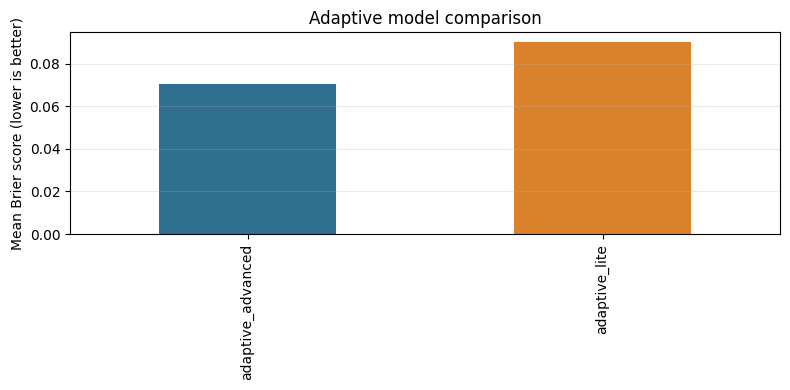

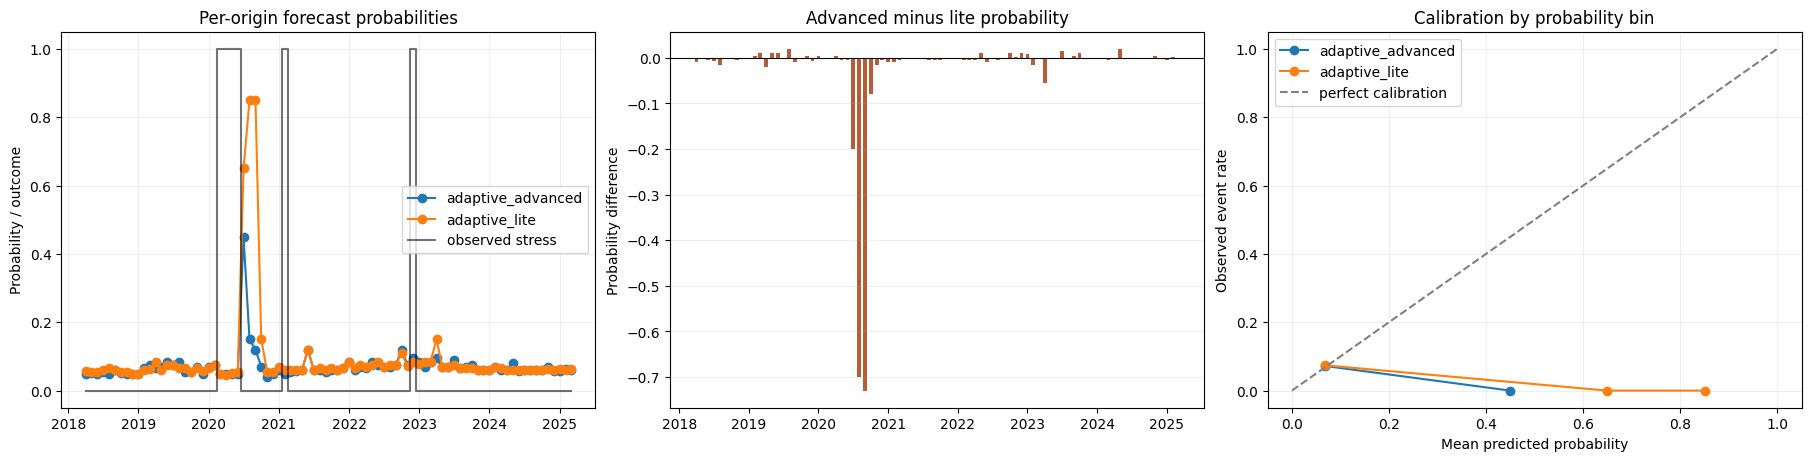

Risk direction agrees on 50 of 84 origins.


,forecast_date,adaptive_advanced_probability,adaptive_lite_probability,adaptive_advanced_brier,adaptive_lite_brier,adaptive_advanced_risk_direction,adaptive_lite_risk_direction,adaptive_advanced_rationale,adaptive_lite_rationale,adaptive_advanced_supporting_evidence,adaptive_lite_supporting_evidence,adaptive_advanced_countervailing_evidence,adaptive_lite_countervailing_evidence,observed_outcome,probability_delta_advanced_minus_lite,risk_direction_agrees
0,2018-04-01,0.05,0.058,0.0025,0.003364,down,down,Strong three-month IPMAN growth of 0.88% and r...,"The 3-month IPMAN change is positive (+0.88%),...",Positive three-month IPMAN growth of 0.88% and...,None are material,A slight one-month decline in IPMAN of -0.26%,"3-month IPMAN change is positive at 0.88%, sig...",0,-0.008,True
1,2018-05-01,0.052,0.055,0.002704,0.003025,down,down,"Strong macro indicators, including high XLI an...",The 3-month IPMAN contraction of -0.5% is well...,Strong XLI 3-month return of 12.07% and SPY 3-...,3-month IPMAN contraction of -0.5% is signific...,Recent 3-month IPMAN decline of -0.50% and 1-m...,None are material; macroeconomic indicators li...,0,-0.003,True
2,2018-06-01,0.05,0.055,0.0025,0.003025,down,down,Strong recent IPMAN growth (+0.87% monthly) an...,"IPMAN shows positive 3-month growth (0.29%), r...",Positive 1-month IPMAN growth of 0.87% and 3-m...,None are material,Slightly elevated VIX at 19.85 and a narrowing...,Positive 3-month IPMAN growth of 0.29% and sta...,0,-0.005,True
3,2018-07-01,0.055,0.061,0.003025,0.003721,down,neutral,With three-month IPMAN growth positive at 0.50...,The 3-month IPMAN change is positive (+0.497%)...,Slight negative 1-month IPMAN change of -0.05%...,3-month IPMAN change is positive at 0.497%,Positive 3-month IPMAN growth of 0.50% and a 0...,1-month IPMAN change is slightly negative at -...,0,-0.006,False
4,2018-08-01,0.05,0.065,0.0025,0.004225,down,up,Strong recent IPMAN growth of 1.57% over three...,"IPMAN shows positive 3-month growth (+1.57%), ...",Strong 3-month IPMAN growth of 1.57% and low u...,Negative 3-month returns for SPY (-5.79%) and ...,"Negative 3-month equity returns (SPY -5.79%, X...","IPMAN 3-month growth is positive at 1.57%, sig...",0,-0.015,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2024-11-01,0.068,0.064,0.004624,0.004096,neutral,neutral,Recent 1-month IPMAN decline of -0.78% and inv...,The 3-month IPMAN contraction of -0.41% remain...,Recent 1-month IPMAN decline of -0.78% and inv...,3-month IPMAN contraction of -0.41% is signifi...,Strong 3-month SPY return of 10.08% and XLI re...,None are material; current macro signals and I...,0,0.004,True
80,2024-12-01,0.058,0.06,0.003364,0.0036,down,down,With 1-month IPMAN rebounding by 0.48% and the...,The 3-month IPMAN contraction of -0.49% remain...,Recent 1-month IPMAN growth of 0.48% indicates...,3-month trailing IPMAN contraction of -0.49% i...,"The yield curve remains inverted at -0.20%, an...",None are material.,0,-0.002,True
81,2025-01-01,0.058,0.0622,0.003364,0.003869,down,neutral,With trailing three-month IPMAN contraction at...,The current 3-month IPMAN contraction of -0.87...,Trailing three-month IPMAN contraction of -0.8...,Trailing 3-month IPMAN contraction of -0.87% i...,"Recent one-month IPMAN declined by -0.56%, ind...",Positive 3-month and 12-month SPY and XLI retu...,0,-0.0042,False
82,2025-02-01,0.062,0.06,0.003844,0.0036,neutral,down,IPMAN's 3-month contraction of -0.75% remains ...,The current 3-month IPMAN contraction of -0.75...,"Recent consecutive monthly declines in IPMAN, ...",Current 3-month IPMAN contraction of -0.75% is...,The 3-month IPMAN change of -0.75% is well abo...,None are material.,0,0.002,False


In [3]:
import matplotlib.pyplot as plt

if results:
    score_frame = pd.DataFrame([
        {'model': variant_id, 'mean_brier': float(result.mean_score)}
        for variant_id, result in results.items()
    ]).sort_values('mean_brier')
    ax = score_frame.plot.bar(x='model', y='mean_brier', legend=False, figsize=(8, 4), color=['#2f6f8f', '#d9822b'])
    ax.set_title('Adaptive model comparison')
    ax.set_ylabel('Mean Brier score (lower is better)')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

    origin_frames = []
    for variant_id, result in results.items():
        for prediction, score in zip(result.predictions, result.scores):
            probability = float(prediction.payload.probability)
            zero_score = probability**2
            one_score = (1.0 - probability)**2
            distances = {0: abs(float(score) - zero_score), 1: abs(float(score) - one_score)}
            outcome = min(distances, key=distances.get)
            if distances[outcome] > 1e-5:
                raise ValueError('Could not recover a binary outcome from a Brier score.')
            origin_frames.append({
                'model': variant_id,
                'forecast_date': pd.Timestamp(prediction.forecast_date),
                'probability': probability,
                'outcome': outcome,
                'brier': float(score),
                'risk_direction': prediction.metadata['direction'],
                'rationale': prediction.metadata['rationale'],
                'supporting_evidence': '; '.join(prediction.metadata['supporting_evidence']),
                'countervailing_evidence': '; '.join(prediction.metadata['countervailing_evidence']),
            })
    origin_frame = pd.DataFrame(origin_frames).sort_values(['forecast_date', 'model'])
    wide = origin_frame.pivot(index='forecast_date', columns='model', values='probability')
    comparison_fields = ['probability', 'brier', 'risk_direction', 'rationale', 'supporting_evidence', 'countervailing_evidence']
    decision_comparison = origin_frame.pivot(index='forecast_date', columns='model', values=comparison_fields)
    decision_comparison.columns = [f'{model}_{field}' for field, model in decision_comparison.columns]
    outcomes = origin_frame.drop_duplicates('forecast_date').set_index('forecast_date')['outcome']
    decision_comparison['observed_outcome'] = outcomes
    decision_comparison['probability_delta_advanced_minus_lite'] = (
        decision_comparison['adaptive_advanced_probability'] - decision_comparison['adaptive_lite_probability']
    )
    decision_comparison['risk_direction_agrees'] = (
        decision_comparison['adaptive_lite_risk_direction'] == decision_comparison['adaptive_advanced_risk_direction']
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)
    for model in wide.columns:
        axes[0].plot(wide.index, wide[model], marker='o', label=model)
    axes[0].step(outcomes.index, outcomes, where='mid', color='black', alpha=0.55, label='observed stress')
    axes[0].set_title('Per-origin forecast probabilities')
    axes[0].set_ylabel('Probability / outcome')
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    if {'adaptive_lite', 'adaptive_advanced'}.issubset(wide.columns):
        difference = wide['adaptive_advanced'] - wide['adaptive_lite']
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].bar(difference.index, difference.values, width=20, color='#b85c38')
        axes[1].set_title('Advanced minus lite probability')
        axes[1].set_ylabel('Probability difference')
        axes[1].grid(axis='y', alpha=0.2)
    else:
        axes[1].set_visible(False)

    for model, group in origin_frame.groupby('model'):
        bins = pd.cut(group['probability'], bins=[0, .2, .4, .6, .8, 1], include_lowest=True)
        calibration = group.assign(bin=bins).groupby('bin', observed=False).agg(
            predicted=('probability', 'mean'), observed=('outcome', 'mean'), count=('outcome', 'size'))
        calibration = calibration[calibration['count'] > 0]
        axes[2].plot(calibration['predicted'], calibration['observed'], marker='o', label=model)
    axes[2].plot([0, 1], [0, 1], '--', color='gray', label='perfect calibration')
    axes[2].set_title('Calibration by probability bin')
    axes[2].set_xlabel('Mean predicted probability')
    axes[2].set_ylabel('Observed event rate')
    axes[2].legend()
    axes[2].grid(alpha=0.2)
    plt.show()

    print(f"Risk direction agrees on {decision_comparison['risk_direction_agrees'].sum()} of {len(decision_comparison)} origins.")
    display(decision_comparison.reset_index())
else:
    print('Run the comparison to render score, per-origin, difference, and calibration plots.')